In [12]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import pandas as pd

In [13]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data -O iris.csv

--2026-04-09 01:34:57--  https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘iris.csv’

iris.csv                [ <=>                ]   4.44K  --.-KB/s    in 0s      

2026-04-09 01:34:57 (59.6 MB/s) - ‘iris.csv’ saved [4551]



Dữ liệu X ban đầu (5 dòng đầu):
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Nhãn Y (5 dòng đầu):
 ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']

Dữ liệu X mới sau PCA (5 dòng đầu):
 [[-2.68420713 -0.32660731]
 [-2.71539062  0.16955685]
 [-2.88981954  0.13734561]
 [-2.7464372   0.31112432]
 [-2.72859298 -0.33392456]]


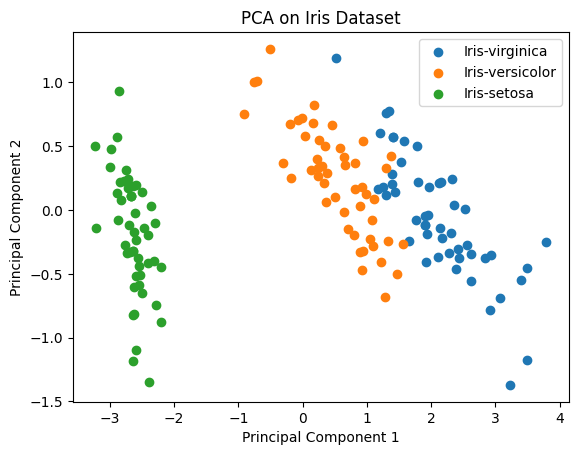

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class PCA:

    def __init__(self, n_dimension: int):
        self.n_dimension = n_dimension

    def fit_transform(self, X):

        mean = np.mean(X, axis=0)
        X_centered = X - mean
        cov = X_centered.T.dot(X_centered) / X_centered.shape[0]
        eigen_values, eigen_vectors = np.linalg.eig(cov)
        select_index = np.argsort(eigen_values)[::-1][:self.n_dimension]
        U = eigen_vectors[:, select_index]
        X_new = X_centered.dot(U)
        return X_new

if __name__ == "__main__":
    data = pd.read_csv('iris.csv', header=None)
    X = data.values[:, :4].astype(float)
    Y = data.values[:, 4]

    print("Dữ liệu X ban đầu (5 dòng đầu):\n", X[:5])
    print("Nhãn Y (5 dòng đầu):\n", Y[:5])

    # Khởi tạo và chạy PCA
    pca = PCA(n_dimension=2)
    new_X = pca.fit_transform(X)

    print("\nDữ liệu X mới sau PCA (5 dòng đầu):\n", new_X[:5])

    # 3. Thụt lề đúng cho vòng lặp vẽ biểu đồ
    for label in set(Y):
        X_class = new_X[Y == label]
        plt.scatter(X_class[:, 0], X_class[:, 1], label=label)

    # 4. Mở comment plt.legend() để biểu đồ hiển thị chú thích các loại hoa
    plt.legend()
    plt.title("PCA on Iris Dataset")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()